## 2.1 DataFrame objects

In [149]:
import pandas as pd

df = pd.DataFrame({
    "Year": list(range(2015, 2020)),
    "Observation": [123, 39, 31, 69, 110]
})

df



,Year,Observation
0,2015,123
1,2016,39
2,2017,31
3,2018,69
4,2019,110


In [150]:
df.index

RangeIndex(start=0, stop=5, step=1)

In [151]:
df.columns

Index(['Year', 'Observation'], dtype='str')

In [152]:
# type(df["Year"])
df["Year"]

0    2015
1    2016
2    2017
3    2018
4    2019
Name: Year, dtype: int64

In [153]:
year_df = df.set_index("Year")
year_df

,Observation
Year,
2015,123
2016,39
2017,31
2018,69
2019,110


In [154]:
repr(pd.Timestamp("2020-01"))

"Timestamp('2020-01-01 00:00:00')"

In [155]:
repr(pd.Period("2020-01"))

"Period('2020-01', 'M')"

In [156]:
print(repr(pd.Timestamp("2020")))
print(repr(pd.Timestamp("2020-01-01 12:34")))
print(repr(pd.Period("2020-01-01")))
print(repr(pd.Period("2020-01-01", freq="M")))

Timestamp('2020-01-01 00:00:00')
Timestamp('2020-01-01 12:34:00')
Period('2020-01-01', 'D')
Period('2020-01', 'M')


## 2.2 Time plots

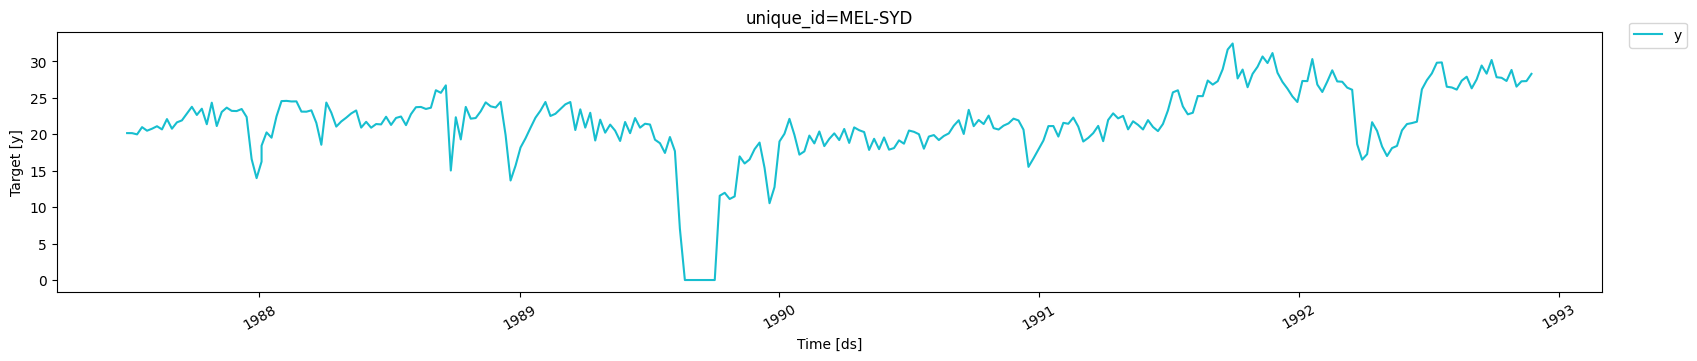

In [157]:
from utilsforecast.plotting import plot_series


melsyd_economy = (
    pd.read_csv("../data/tsibbledata/ansett.csv")
    .rename(
        columns={
            "Week": "ds",
            "Airports": "unique_id",
            "Passengers": "y",
        }
    )
    .loc[
        lambda x: (x["unique_id"] == "MEL-SYD")
        & (x["Class"] == "Economy")
    ]
    .assign(y=lambda x: x["y"] / 1000)
)

melsyd_economy["ds"] = pd.to_datetime(
    melsyd_economy["ds"] + "-1",
    format="%Y W%W-%w"
)

plot_series(
    df=melsyd_economy,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
)

In [158]:
total_cost_df = pd.read_csv("../data/fpp3/total_cost_df.csv")

total_cost_df["Month"] = pd.to_datetime(total_cost_df["Month"])

total_cost_df

,Month,TotalC,Cost
0,1991-07-01,3526591.0,3.53
1,1991-08-01,3180891.0,3.18
2,1991-09-01,3252221.0,3.25
3,1991-10-01,3611003.0,3.61
4,1991-11-01,3565869.0,3.57
...,...,...,...
199,2008-02-01,21654285.0,21.65
200,2008-03-01,18264945.0,18.26
201,2008-04-01,23107677.0,23.11
202,2008-05-01,22912510.0,22.91


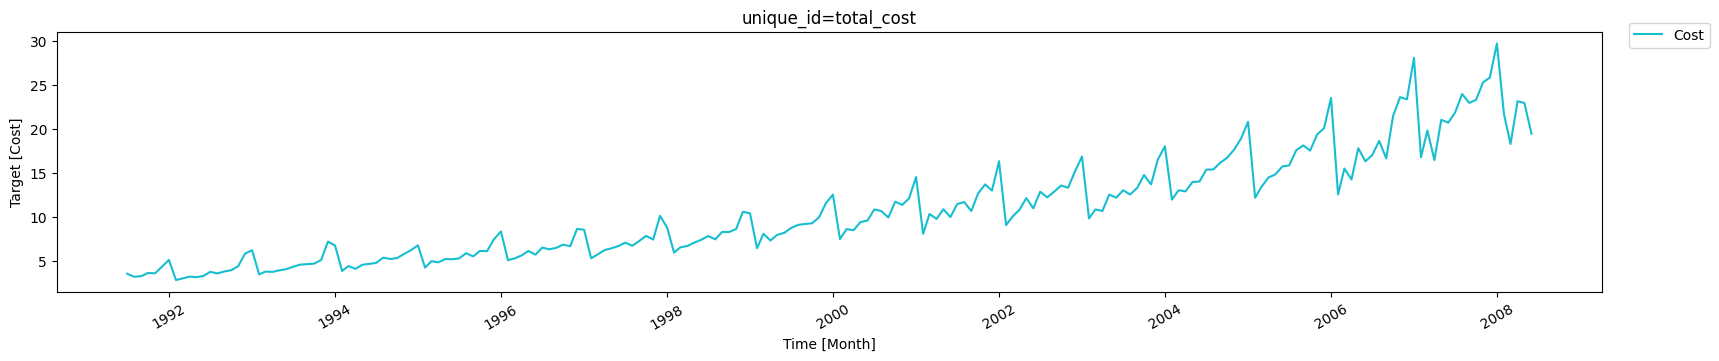

In [159]:
total_cost_df["unique_id"] = "total_cost"

plot_series(
    df=total_cost_df,
    id_col="unique_id",
    time_col="Month",
    target_col="Cost",
)

## 2.4 Seasonal plots

/var/folders/97/hpk2hvlx4_9byx9540r32ftc0000gn/T/ipykernel_52479/1559597077.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


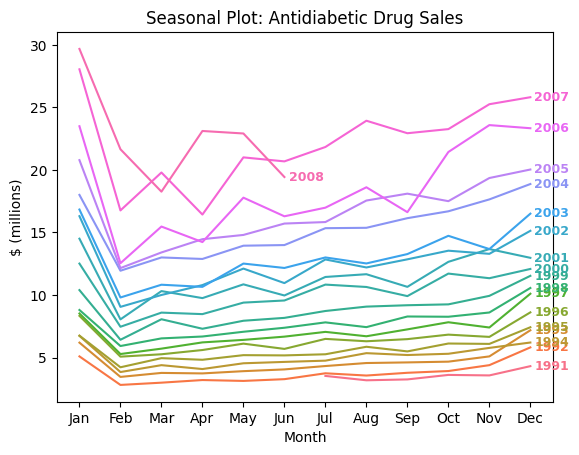

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt 

df = total_cost_df.assign(
    Month_name=total_cost_df["Month"].dt.strftime("%b"),
    Year=total_cost_df["Month"].dt.year,
    Month_num=total_cost_df["Month"].dt.month,
)
unique_years = df["Year"].unique()
year_palette = sns.color_palette("husl", n_colors=len(unique_years))
fig, ax = plt.subplots()
sns.lineplot(data=df, x="Month_num", y="Cost",
  hue="Year", palette=year_palette, legend=False, ax=ax)

ax.set(
    title="Seasonal Plot: Antidiabetic Drug Sales",
    xlabel="Month",
    ylabel="$ (millions)",
    xticks=range(1, 13),
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ]
)
min_year = unique_years.min()
for year, subset in df.groupby("Year"):
    x = subset["Month_num"].iloc[-1] + .1
    y = subset["Cost"].iloc[-1]
    color = year_palette[year - min_year]
    ax.text(x, y, str(year),
        ha="left", va="center", fontsize=9, weight="bold", color=color)
fig.show()

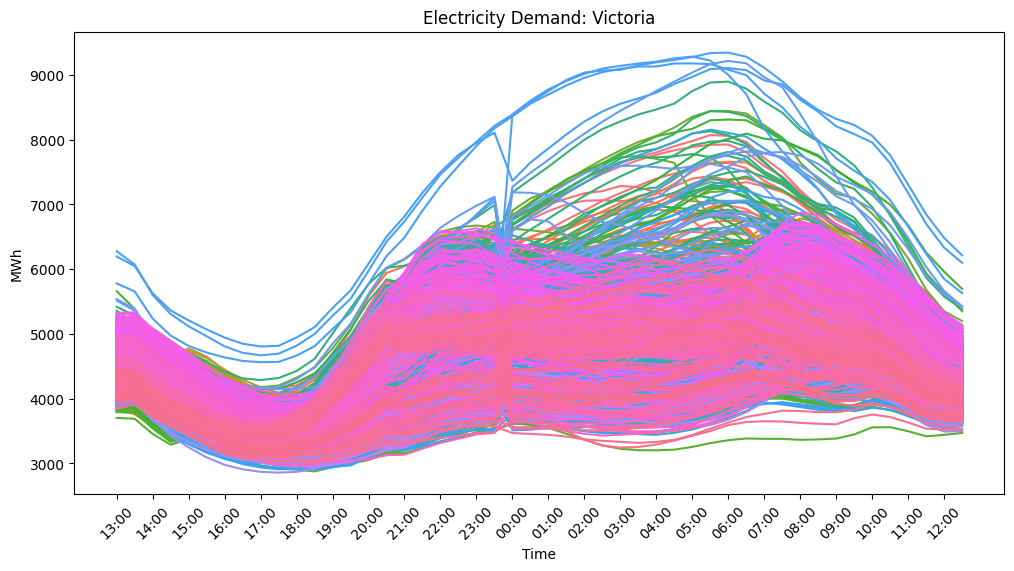

In [161]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

vic_elec_df = pd.read_csv(
    "../data/tsibbledata/vic_elec.csv",
    parse_dates=["Time"]
)

df = vic_elec_df.assign(
    hour_minute=lambda x: x["Time"].dt.strftime("%H:%M"),
    day=lambda x: x["Time"].dt.date,
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="hour_minute",
    y="Demand",
    hue="day",
    palette="husl",
    legend=False,
    ax=ax
)

ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",
)

unique_ticks = df["hour_minute"].unique()
ticks = range(0, len(unique_ticks), 2)
ticklabels = unique_ticks[::2]

ax.set_xticks(ticks)
ax.set_xticklabels(ticklabels, rotation=45)

plt.show()

/var/folders/97/hpk2hvlx4_9byx9540r32ftc0000gn/T/ipykernel_52479/1339268892.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  week=lambda x: x["ds"].dt.to_period("W").dt.start_time,


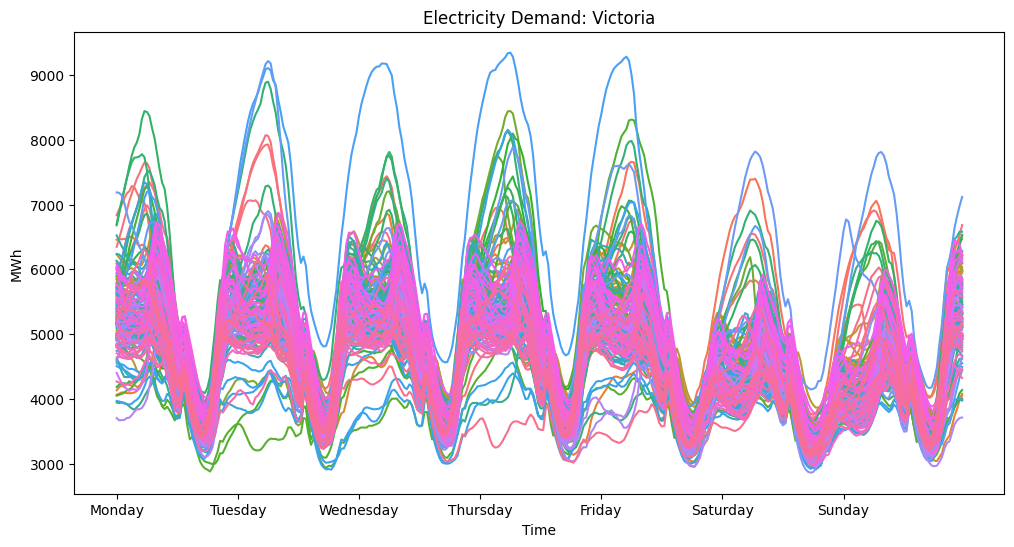

In [162]:
df = (
    vic_elec_demand
    .loc[lambda x: x["ds"].between("2012-01-02", "2014-12-28 23:59")]
    .assign(
        week=lambda x: x["ds"].dt.to_period("W").dt.start_time,
        time_in_week=lambda x: (
            x["ds"].dt.dayofweek * 48
            + x["ds"].dt.hour * 2
            + x["ds"].dt.minute // 30
        )
    )
)

unique_weeks = df["week"].unique()
palette = sns.color_palette("husl", n_colors=len(unique_weeks))
color_map = dict(zip(unique_weeks, palette))

fig, ax = plt.subplots(figsize=(12, 6))

for week, df_week in df.groupby("week"):
    df_week.plot(
        x="time_in_week",
        y="y",
        ax=ax,
        color=color_map[week],
        legend=False,
    )

ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",
)

ax.set_xticks([0, 48, 96, 144, 192, 240, 288])
ax.set_xticklabels(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

plt.show()

## 2.5 Seasonal subseries plots

In [163]:
tourism = pd.read_csv("../data/tsibble/tourism.csv")

trips = (
    tourism
    .loc[lambda x: x["Purpose"] == "Holiday"]
    .assign(
        ds=lambda x: pd.PeriodIndex(
            x["Quarter"].str.replace(" ", ""),
            freq="Q"
        ).to_timestamp()
    )
    .groupby(["State", "ds"], as_index=False)
    .agg(y=("Trips", "sum"))
)

trips

,State,ds,y
0,ACT,1998-01-01,196.218550
1,ACT,1998-04-01,126.770597
2,ACT,1998-07-01,110.679645
3,ACT,1998-10-01,170.472206
4,ACT,1999-01-01,107.779245
...,...,...,...
635,Western Australia,2016-10-01,982.752589
636,Western Australia,2017-01-01,1134.352019
637,Western Australia,2017-04-01,997.852225
638,Western Australia,2017-07-01,879.988533


/var/folders/97/hpk2hvlx4_9byx9540r32ftc0000gn/T/ipykernel_52479/3888130340.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


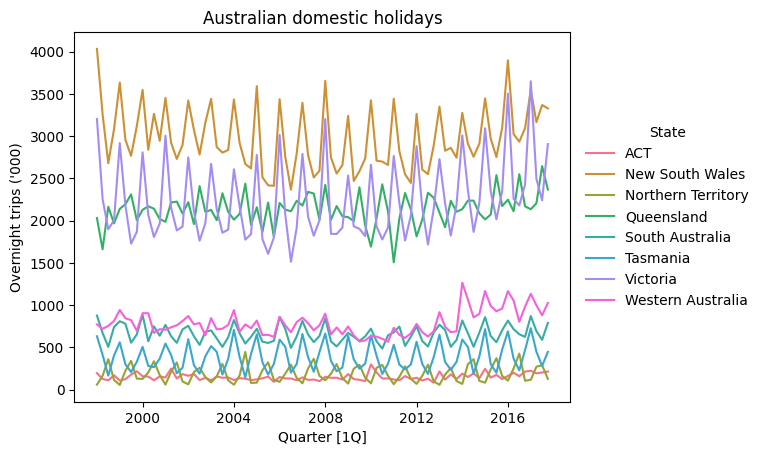

In [164]:
fig, ax = plt.subplots()
palette = sns.color_palette("husl", trips["State"].nunique())
sns.lineplot(data=trips, x="ds", y="y", hue="State", palette=palette)
ax.set(
    title="Australian domestic holidays",
    ylabel="Overnight trips ('000)",
    xlabel="Quarter [1Q]",
)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=False, borderaxespad=0, title="State")
fig.show()

/var/folders/97/hpk2hvlx4_9byx9540r32ftc0000gn/T/ipykernel_52479/3514072415.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


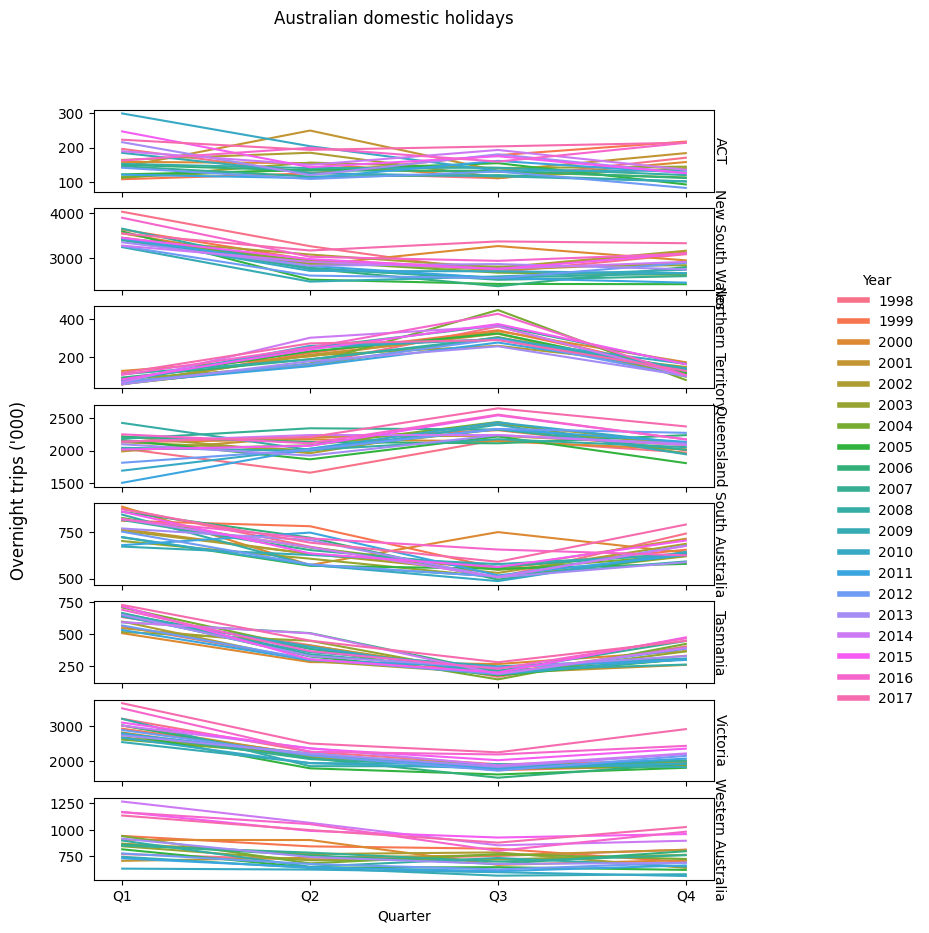

In [165]:
df = trips.assign(
    Quarter="Q" + trips["ds"].dt.quarter.astype("string"),
    Year=trips["ds"].dt.year,
)
num_states, num_years = df[["State", "Year"]].nunique()
palette = sns.color_palette("husl", num_years)
fig, axes = plt.subplots(num_states, sharex=True, figsize=(8, 10))
for ax, (state, state_df) in zip(axes, df.groupby("State")):
    sns.lineplot(data=state_df, x="Quarter", y="y",
        hue="Year", palette=palette, ax=ax)
    ax.get_legend().remove()
    ax.set(ylabel="")
    ax.text(1.02, 0.5, state, va="center", ha="right", rotation=270,
        size="medium", transform=ax.transAxes)
handles, labels = ax.get_legend_handles_labels()
for h in handles:
    h.set(linewidth=4)
fig.legend(handles, labels, title="Year", loc="center left",
    bbox_to_anchor=(1.05, 0.5), frameon=False, borderaxespad=0)
fig.suptitle("Australian domestic holidays")
fig.supylabel("Overnight trips ('000)")
fig.show()

/var/folders/97/hpk2hvlx4_9byx9540r32ftc0000gn/T/ipykernel_52479/4083804369.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


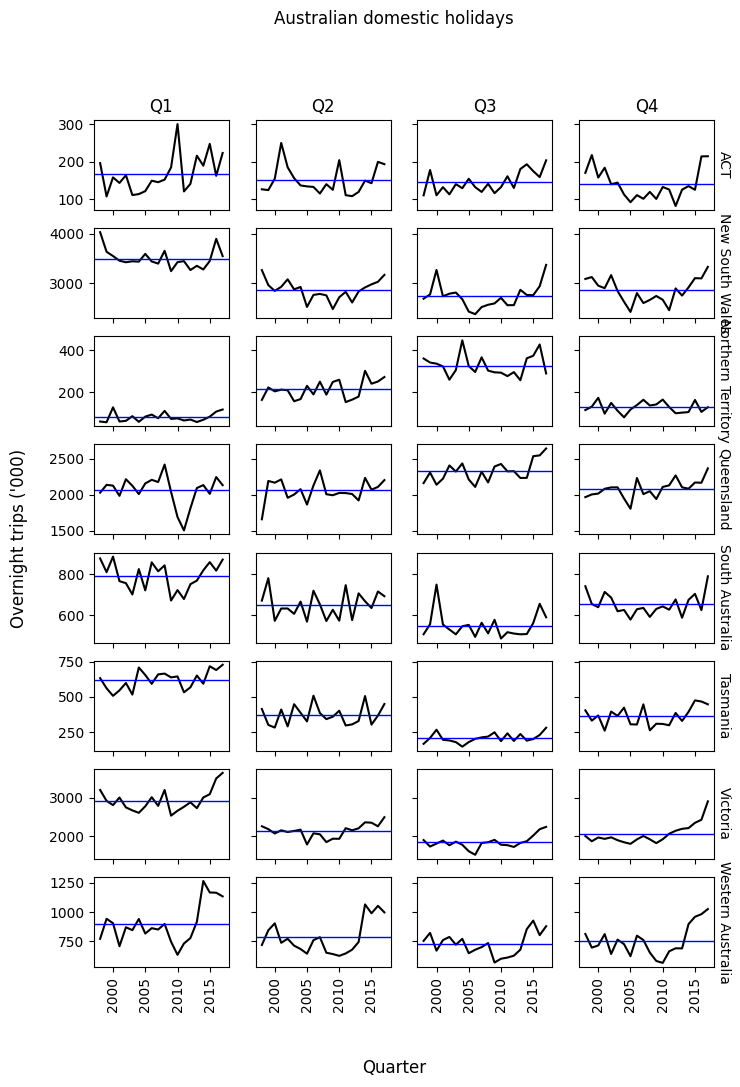

In [166]:
fig, axes = plt.subplots(num_states, 4,
    sharex=True, sharey="row", figsize=(8, 11))
for ax, ((state, quarter), sq_df) in zip(
        axes.flat, df.groupby(["State", "Quarter"])):
    ax.plot(sq_df["Year"], sq_df["y"], color="k")
    ax.axhline(sq_df["y"].mean(), color="b", linewidth=1)
    ax.tick_params(axis="x", rotation=90)
    xticks = sq_df["Year"].loc[lambda x: (x % 5) == 0]
    if ax in axes[0]:
        ax.set(title=quarter, xticks=xticks)
    if ax in axes[:, -1]:
        ax.text(1.02, 0.5, state, va="center", ha="left", rotation=270,
            size="medium", transform=ax.transAxes)
fig.suptitle("Australian domestic holidays")
fig.supxlabel("Quarter")
fig.supylabel("Overnight trips ('000)")
fig.show()

## 2.6 Scatterplots

In [167]:
tourism = tourism.rename(
    columns={
        "Quarter": "ds",
        "Trips": "y"
    }
)

tourism["ds"] = pd.to_datetime(
    tourism["ds"].str.replace(" Q", "-Q"),
)

tourism 

/var/folders/97/hpk2hvlx4_9byx9540r32ftc0000gn/T/ipykernel_52479/3669631840.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tourism["ds"] = pd.to_datetime(


,ds,Region,State,Purpose,y
0,1998-01-01,Adelaide,South Australia,Business,135.077690
1,1998-04-01,Adelaide,South Australia,Business,109.987316
2,1998-07-01,Adelaide,South Australia,Business,166.034687
3,1998-10-01,Adelaide,South Australia,Business,127.160464
4,1999-01-01,Adelaide,South Australia,Business,137.448533
...,...,...,...,...,...
24315,2016-10-01,Yorke Peninsula,South Australia,Visiting,33.672151
24316,2017-01-01,Yorke Peninsula,South Australia,Visiting,46.223014
24317,2017-04-01,Yorke Peninsula,South Australia,Visiting,50.582837
24318,2017-07-01,Yorke Peninsula,South Australia,Visiting,27.766728


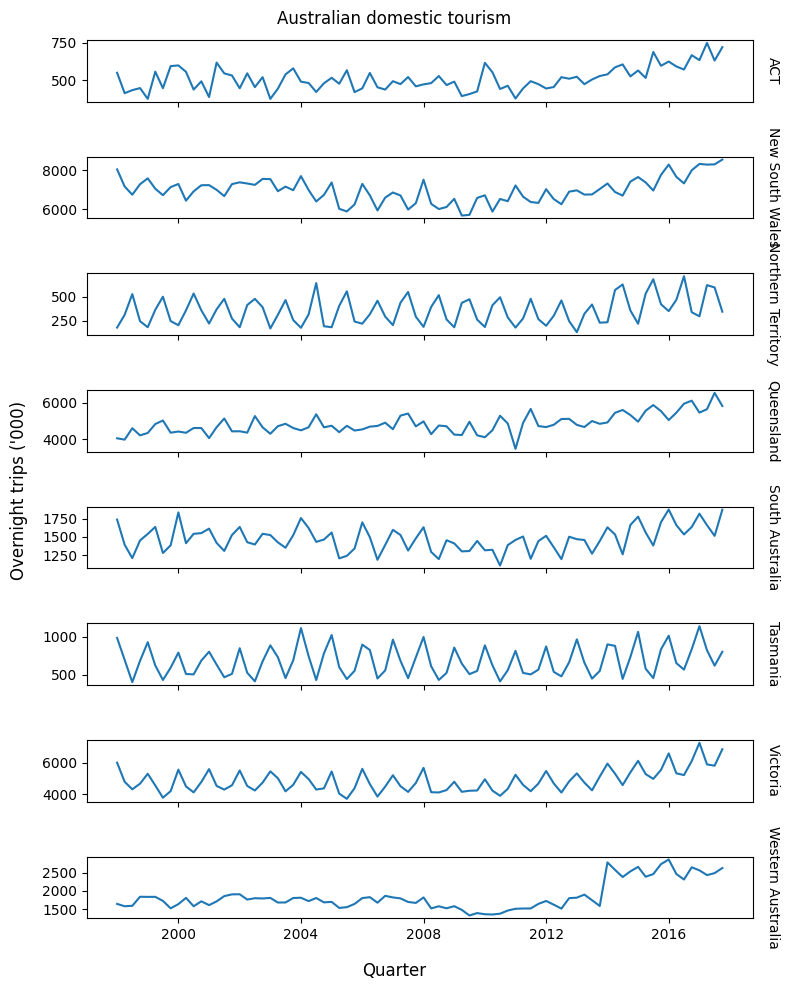

In [168]:
import matplotlib.pyplot as plt

visitors = tourism.groupby(
    ["State", "ds"],
    as_index=False
)["y"].sum()

num_states = visitors["State"].nunique()

fig, axes = plt.subplots(
    num_states,
    1,
    sharex=True,
    figsize=(8, 10)
)

for ax, (state, state_df) in zip(
    axes,
    visitors.groupby("State")
):
    ax.plot(state_df["ds"], state_df["y"])

    ax.text(
        1.02,
        0.5,
        state,
        va="center",
        ha="left",
        rotation=270,
        transform=ax.transAxes,
    )

fig.suptitle("Australian domestic tourism")
fig.supxlabel("Quarter")
fig.supylabel("Overnight trips ('000)")

plt.tight_layout()
plt.show()

/var/folders/97/hpk2hvlx4_9byx9540r32ftc0000gn/T/ipykernel_52479/2087671794.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


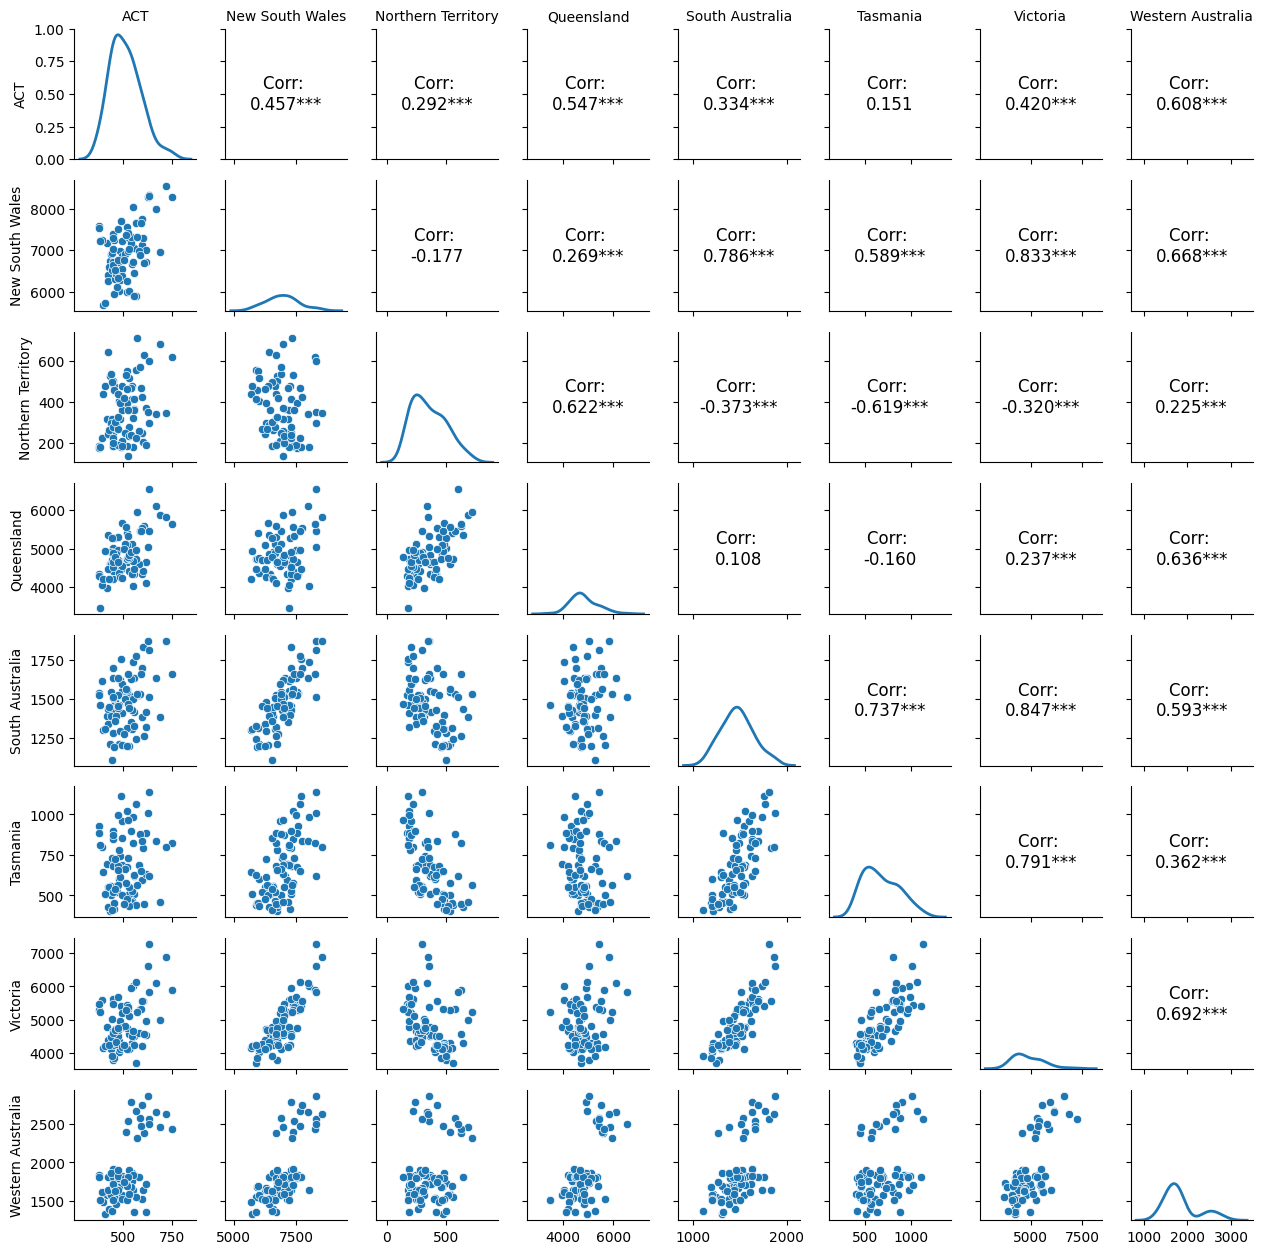

In [169]:
from scipy.stats import pearsonr

df = visitors.pivot(index="ds", columns="State", values="y")

def corrfunc(x, y, **kws):
    r, pvalue = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(
        f"Corr: \n{r:.3f}{'***' if pvalue < 0.05 else ''}",
        xy=(0.5, 0.5), xycoords="axes fraction",
        ha="center", va="center", fontsize=12)

g = sns.PairGrid(df, height=1.6)
g.map_lower(sns.scatterplot)
g.map_upper(corrfunc)
g.map_diag(sns.kdeplot, lw=2)
g.set(xlabel="")
for i, col in enumerate(df.columns):
    g.axes[0, i].set_title(col, size="medium")
fig.show()